/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, 

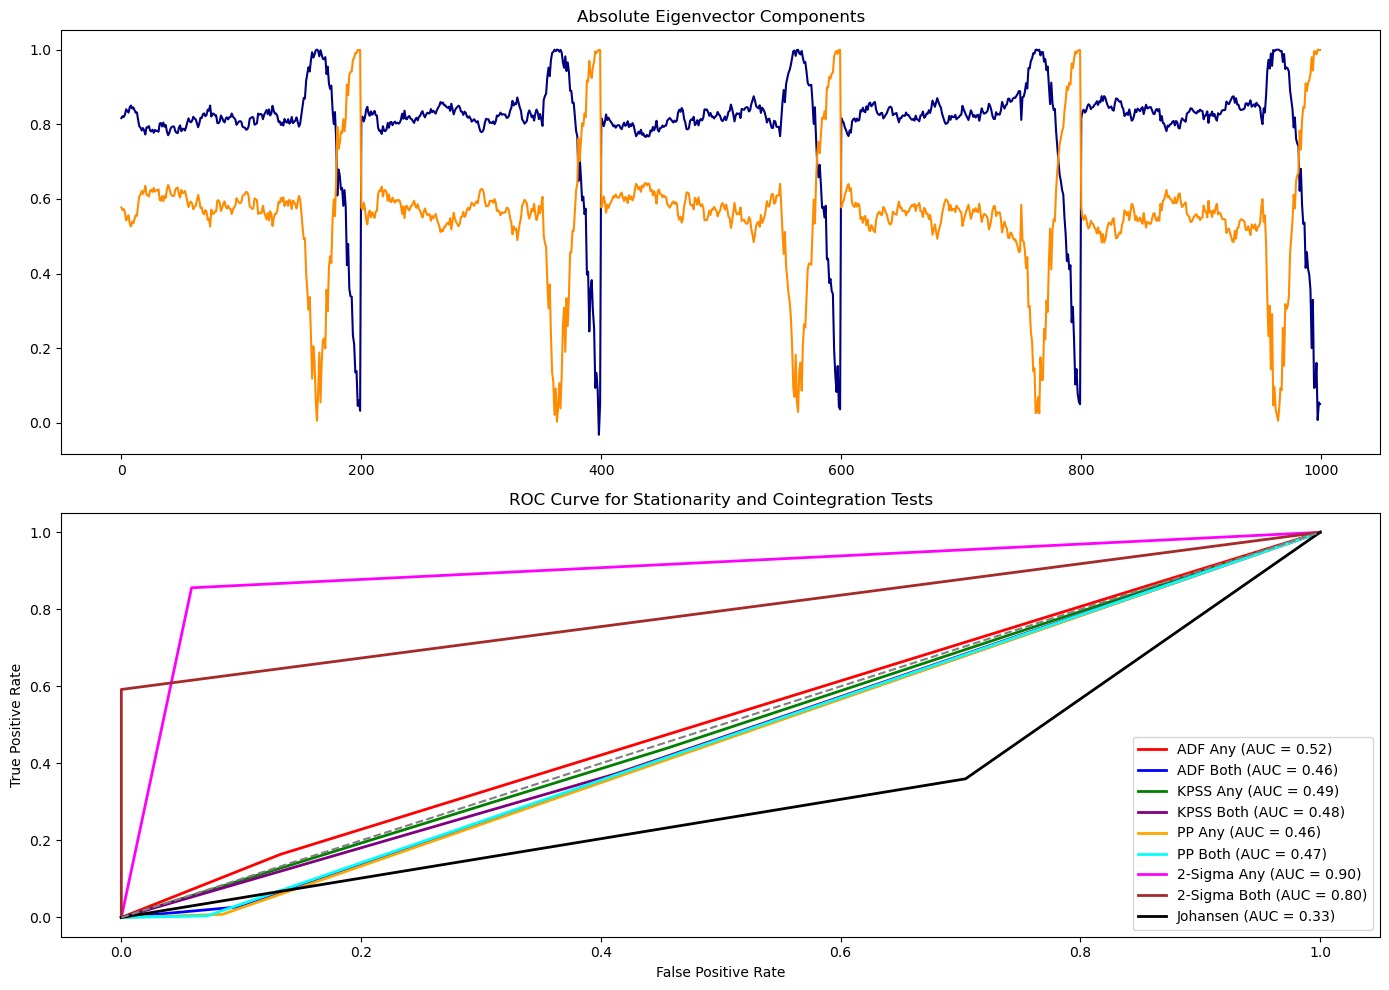

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.metrics import roc_curve, auc

def generate_2d_eigenvector_ts(n_periods=1000, segment_length_1=150, segment_length_2=50, seed=42):
    # Init system state
    np.random.seed(seed)
    vecs = []
    change_points = []
    alpha = 0.9
    noise_std = 0.01
    i = 0
    t = 0

    # Generate segments of time series
    # Alternating between stationary and non-stationary segments
    while t < n_periods:
        if i % 2 == 0:
            seg_len = min(segment_length_1, n_periods - t)
            segment = np.zeros((seg_len, 2))
            segment[0] = [np.sqrt(2/3), -np.sqrt(1/3)]
            for j in range(1, seg_len):
                segment[j,0] = alpha * segment[j - 1,0] + (1-alpha)*segment[0,0] + np.random.normal(0, noise_std)
                segment[j,1] = -np.sqrt(1 - segment[j,0]**2)
        else:
            seg_len = min(segment_length_2, n_periods - t)
            drift_angle_start = np.arcsin(vecs[-1][0])
            drift = np.linspace(drift_angle_start, np.pi, seg_len) + np.random.normal(0,0.05,(seg_len,2))
            segment = np.zeros((seg_len, 2))
            segment[:, 0] = np.sin(drift[:,0])
            segment[:, 1] = np.cos(drift[:,0])

        # Get absolute eigenvector components and update system state
        segment[:,1] = np.abs(segment[:,1])
        vecs.append(segment)
        t += segment.shape[0]
        i += 1
        change_points.append(t)

    vecs = np.vstack(vecs)
    return vecs, change_points[:-1]


# Test statistics
def rolling_tests(ts, window=50, alpha=0.05):
    n_variables = ts.shape[1]
    adf_results, kpss_results, pp_results, sigma_results = [], [], [], []

    for i in range(window, len(ts)):
        adf_flags, kpss_flags, pp_flags, sigma_flags = [], [], [], []

        for var in range(n_variables):
            adf_p = adfuller(ts[i-window:i, var])[1]
            kpss_p = kpss(ts[i-window:i, var], regression='c')[1]
            pp_p = PhillipsPerron(ts[i-window:i, var]).pvalue

            adf_flags.append(adf_p < alpha)
            kpss_flags.append(kpss_p > alpha)
            pp_flags.append(pp_p < alpha)

            window_std = np.std(ts[i-window:i, var])
            past_std = np.mean([np.std(ts[max(0, j-window):j, var]) for j in range(i-window, i)])
            sigma_flags.append(window_std > 2 * past_std)

        adf_results.append(adf_flags)
        kpss_results.append(kpss_flags)
        pp_results.append(pp_flags)
        sigma_results.append(sigma_flags)

    return np.array(adf_results), np.array(kpss_results), np.array(pp_results), np.array(sigma_results)
def johansen_cointegration_test(ts, window=50, significance_level=0.05):
    n_obs = ts.shape[0]
    cointegration_results = []

    for i in range(window, n_obs):
        try:
            result = coint_johansen(ts[i-window:i], det_order=0, k_ar_diff=1)
            trace_statistic = result.lr1
            critical_values = result.cvt[:, 1]
            cointegration_results.append(np.any(trace_statistic > critical_values))
        except np.linalg.LinAlgError:
            cointegration_results.append(False)

    return np.array(cointegration_results)

def generate_true_labels(n_periods=1000, segment_length_1=150, segment_length_2=50):
    t = 0
    i = 0
    labels = []
    while t < n_periods:
        if i % 2 == 0:
            seg_len = min(segment_length_1, n_periods - t)
            segment = np.zeros(seg_len)
        else:
            seg_len = min(segment_length_2, n_periods - t)
            segment = np.ones(seg_len)

        labels.extend(segment)

        t += segment.shape[0]
        i += 1
    labels = np.array(labels)
    # Ignore the first 50 points as that is rolling window initialization
    return labels[50:].astype(int)

def plot_full_roc_and_series(ts, true_labels, test_results, window=50):

    time_idx = np.arange(window, len(ts))
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1]})

    # Top subplot: Eigenvector components
    axes[0].plot(ts[:, 0], color='navy')
    axes[0].plot(ts[:, 1], color='darkorange')
    axes[0].set_title("Absolute Eigenvector Components")

    # Bottom subplot: ROC
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown', 'black']
    for (name, pred), color in zip(test_results.items(), colors):
        fpr, tpr, _ = roc_curve(true_labels, pred)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.2f})')

    axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1].set_title("ROC Curve for Stationarity and Cointegration Tests")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc='lower right')
    axes[1].grid(False)

    plt.tight_layout()
    plt.savefig("Figures/methods_roc.pdf", dpi=1200, bbox_inches='tight')
    plt.show()

# === Run Full Pipeline ===
segment_length = 50
ts, change_points = generate_2d_eigenvector_ts()

# Get test results
adf, kpss, pp, sigma = rolling_tests(ts)
johansen = johansen_cointegration_test(ts)

# Build test output variants
results_dict = {
    "ADF Any": adf.any(axis=1).astype(int),
    "ADF Both": adf.all(axis=1).astype(int),
    "KPSS Any": kpss.any(axis=1).astype(int),
    "KPSS Both": kpss.all(axis=1).astype(int),
    "PP Any": pp.any(axis=1).astype(int),
    "PP Both": pp.all(axis=1).astype(int),
    "2-Sigma Any": sigma.any(axis=1).astype(int),
    "2-Sigma Both": sigma.all(axis=1).astype(int),
    "Johansen": johansen.astype(int)
}

# Generate ground truth
true_labels = generate_true_labels()
# Plot ROC for all
plot_full_roc_and_series(ts, true_labels, results_dict)